# 02a - Cylinder Skeletonization Demo


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

from mcf2swc import *

import logging
logging.basicConfig(level=logging.INFO)

## Create and Visualize Cylinder

In [2]:
# Create a cylinder mesh
mesh = example_mesh(kind="cylinder")

mm = MeshManager(mesh)
mm.print_mesh_analysis()
mm.visualize_mesh_3d(title="Original Cylinder", backend="plotly")


INFO:mcf2swc.mesh:Mesh Analysis Report
INFO:mcf2swc.mesh:====================
INFO:mcf2swc.mesh:
Geometry:
INFO:mcf2swc.mesh:  * Vertices: 34
INFO:mcf2swc.mesh:  * Faces: 64
INFO:mcf2swc.mesh:  * Components: 1
INFO:mcf2swc.mesh:  * Volume: 30.61
INFO:mcf2swc.mesh:  * Bounds: [-1.0, -1.0, -5.0] to [1.0, 1.0, 5.0]
INFO:mcf2swc.mesh:
Mesh Quality:
INFO:mcf2swc.mesh:  * Watertight: True
INFO:mcf2swc.mesh:  * Winding Consistent: True
INFO:mcf2swc.mesh:  * Normal Direction: outward
INFO:mcf2swc.mesh:  * Duplicate Vertices: 0
INFO:mcf2swc.mesh:  * Degenerate Faces: 0
INFO:mcf2swc.mesh:
Topology:
INFO:mcf2swc.mesh:  * Genus: 0
INFO:mcf2swc.mesh:  * Euler Characteristic: 2
INFO:mcf2swc.mesh:
No issues detected
INFO:mcf2swc.mesh:
Recommendation:
INFO:mcf2swc.mesh:  Mesh appears to be in good condition.
INFO:mcf2swc.mesh:====================


## Skeletonize the Mesh

In [3]:
pls = PolylinesSkeleton().from_txt("../data/polylines/cylinder.polylines.txt")
skel = build_traced_skeleton_graph(mesh, pls, options=TraceOptions(spacing=1))
print(skel)

INFO:mcf2swc.trace:Tracing start: mesh[V=34,F=64], polylines=1 (pts=4), spacing=1, radius_mode=equivalent_area
INFO:mcf2swc.trace:Polyline 0: input_pts=4 -> samples=11
INFO:mcf2swc.trace:Tracing done: nodes=11, edges=10, samples=11, section=11, fallback=0


SkeletonGraph with 11 nodes and 10 edges


# Plot cross sections and fitting disks

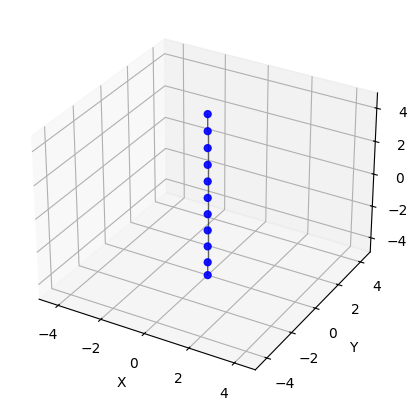

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

In [4]:
skel.plot(node_scale=5)

In [5]:
# write swc to file
skel.to_swc("../data/swc/demo/cylinder.swc")

'# generated by mcf2swc SkeletonGraph.to_swc\n# dfs_roots=1\n# nodes=11 extra_edges=0 duplicates=0\n# type_index=3\n1 3 0.000000 0.000000 4.907961 0.987165 -1\n2 3 0.000022 -0.000091 3.907961 0.987165 1\n3 3 0.000022 -0.000091 2.907961 0.987165 2\n4 3 0.000022 -0.000091 1.907961 0.987165 3\n5 3 0.000022 -0.000091 0.907961 0.987165 4\n6 3 0.000022 -0.000091 -0.092039 0.987165 5\n7 3 0.000022 -0.000091 -1.092039 0.987165 6\n8 3 0.000022 -0.000091 -2.092039 0.987165 7\n9 3 0.000022 -0.000091 -3.092039 0.987165 8\n10 3 0.000022 -0.000091 -4.092039 0.987165 9\n11 3 -0.000000 0.000000 -4.907961 0.987165 10\n'

## Summary

The cylinder segmentation shows:
- **Simple topology**: Each slice typically contains one segment
- **Linear connectivity**: Segments connect in sequence along the z-axis
- **Volume distribution**: End caps may have smaller volumes due to geometry

This represents the baseline case for mesh segmentation with genus = 0 topology.